In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("data/final_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df['Month'] = pd.to_datetime(df['Date']).dt.month
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Time-step feature

In [3]:
df_time_step = df.copy()
df_time_step["Time"] = np.arange(len(df.index))
df_time_step.head()

,Date,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,...,chief,deputy,district,city,region,offense,Total Crimes,Month,Year,Time
0,2016-11-01,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,...,4.0,17.0,6.0,5.0,32.0,7.0,3463.0,11,2016,0
1,2016-12-01,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,...,3.0,9.0,4.0,3.0,14.0,6.0,3214.0,12,2016,1
2,2017-01-01,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,...,5.0,16.0,13.0,3.0,14.0,2.0,1137.0,1,2017,2
3,2017-02-01,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,...,5.0,3.0,3.0,9.0,14.0,3.0,1337.0,2,2017,3
4,2017-03-01,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,...,2.0,18.0,17.0,12.0,23.0,7.0,1566.0,3,2017,4


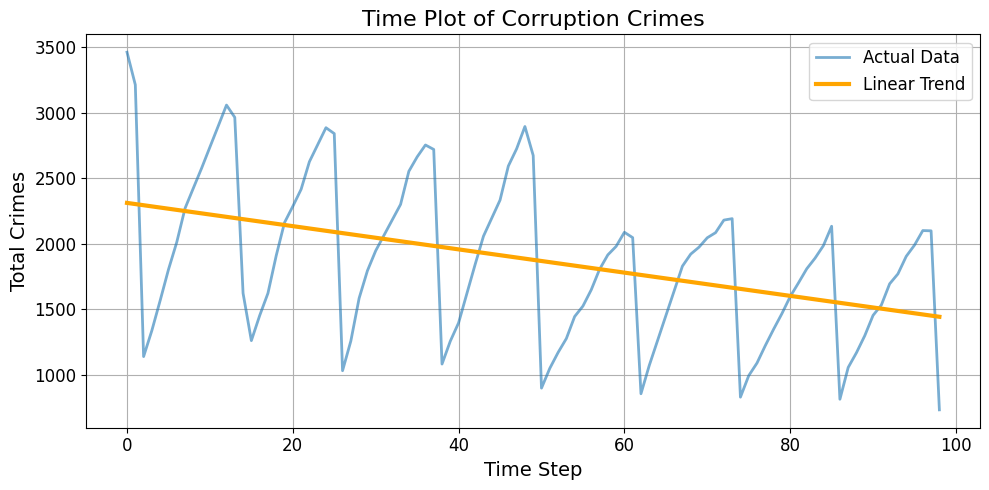

In [ ]:
from sklearn.linear_model import LinearRegression


# Training data
X = df_time_step.loc[:, ["Time"]] # feature
y = df_time_step.loc[:, "Total Crimes"] # target

# Train model
model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

# Plot
plt.figure(figsize=(10, 5))
ax = y.plot(label="Actual Data", linewidth=2, alpha=0.6)
y_pred.plot(ax=ax, label="Linear Trend", linewidth=3, color="orange")

plt.title('Time Plot of Corruption Crimes', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Total Crimes', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Lag plot

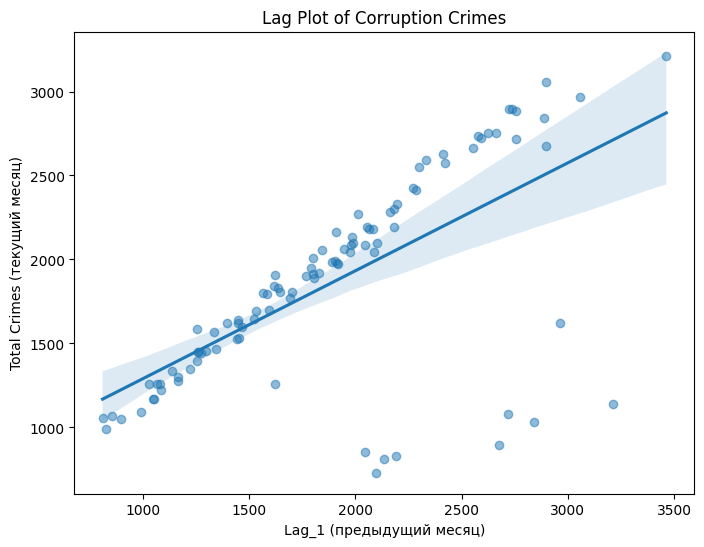

In [5]:
df_lag = df.sort_values("Date").copy()

# Создание лаг-признака
df_lag["Lag_1"] = df_lag["Total Crimes"].shift(1)

# Удаление первой строки (там будет NaN в Lag_1)
df_lag = df_lag.dropna()

# Построение лаг-графика
plt.figure(figsize=(8, 6))
sns.regplot(x=df_lag["Lag_1"], y=df_lag["Total Crimes"], scatter_kws={"alpha": 0.5})
plt.xlabel("Lag_1 (предыдущий месяц)")
plt.ylabel("Total Crimes (текущий месяц)")
plt.title("Lag Plot of Corruption Crimes")
plt.show()

# Оценка коэффициента weight с помощью линейной регрессии

In [6]:
import statsmodels.api as sm

# Загружаем данные
df_weight = df[['Month', 'Year', 'Total Crimes']].copy()

# Создаем лаговую переменную (предыдущий месяц)
df_weight['Lag_1'] = df_weight['Total Crimes'].shift(1)

# Удаляем первую строку (там будет NaN из-за сдвига)
df_weight = df_weight.dropna()

# Определяем переменные
X = df_weight['Lag_1']  # Признак (предыдущий месяц)
y = df_weight['Total Crimes']  # Целевая переменная (текущий месяц)

# Добавляем константу для регрессии
X = sm.add_constant(X)

# Обучаем модель
model = sm.OLS(y, X).fit()

# Выводим результаты
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     71.84
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           2.77e-13
Time:                        16:05:35   Log-Likelihood:                -737.85
No. Observations:                  98   AIC:                             1480.
Df Residuals:                      96   BIC:                             1485.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        645.9822    150.445      4.294      0.0

# Trend: Moving average plot

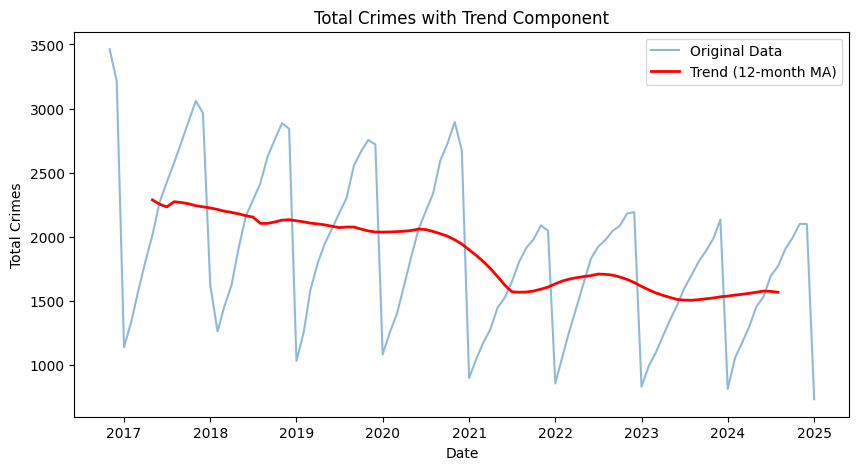

In [7]:
df_moving_avg = df[["Date", "Total Crimes"]].copy()

# Считаем скользящее среднее на 12 месяцев (год)
df_moving_avg['trend'] = df_moving_avg['Total Crimes'].rolling(window=12, center=True).mean()

# df_moving_avg['trend'] = df_moving_avg['trend'].interpolate().ffill().bfill()

# Построение графика
plt.figure(figsize=(10, 5))

# График исходных данных
plt.plot(df_moving_avg['Date'], df_moving_avg['Total Crimes'], label='Original Data', alpha=0.5)

# График тренда
plt.plot(df_moving_avg['Date'], df_moving_avg['trend'], label='Trend (12-month MA)', color='red', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Total Crimes with Trend Component')
plt.legend()
plt.show()

### Trend: Модуль DeterministicProcess из statsmodels.tsa.deterministic упрощает создание временных признаков (time-step features), чтобы включать тренд, сезонность и т.д. в регрессионную модель.

In [8]:
from statsmodels.tsa.deterministic import DeterministicProcess

df_dp = df[["Date", "Total Crimes"]].copy()
df_dp = df_dp.set_index("Date")

# 1) Создаем объект DeterministicProcess
dp = DeterministicProcess(
    index=df_dp.index,       # Индекс с временными метками
    order=1,              # Порядок полиномиального тренда (1 = линейный)
    seasonal=True,        # Включать ли сезонность
    period=12,            # Период сезонности (12 для месячных данных, 7 для дневных и т.д.)
    drop=True             # Удалять ли избыточные признаки (например, один из сезонных «манекенов»)
)

# 2) Генерируем матрицу признаков для "in-sample" (т.е. по тем датам, что у нас есть)
X = dp.in_sample()

# 3) Обучаем модель на полученных признаках
y = df_dp['Total Crimes']  # Наша целевая переменная
X = sm.add_constant(X)  # Добавляем константу, если нужно
model = sm.OLS(y, X).fit()

print(model.summary())

# 4) Если хотим прогнозировать на будущее, генерируем "out-of-sample" признаки
# Предположим, хотим еще 12 шагов вперёд
X_future = dp.out_of_sample(steps=12)
X_future = sm.add_constant(X_future, has_constant='add')

y_forecast = model.predict(X_future)
print(y_forecast)

                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     97.17
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           1.17e-44
Time:                        16:05:35   Log-Likelihood:                -643.45
No. Observations:                  99   AIC:                             1313.
Df Residuals:                      86   BIC:                             1347.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2173.2510     32.354     67.170      0.0

c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
c:\Users\asanb\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\statsmodels\tsa\deterministic.py:441: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


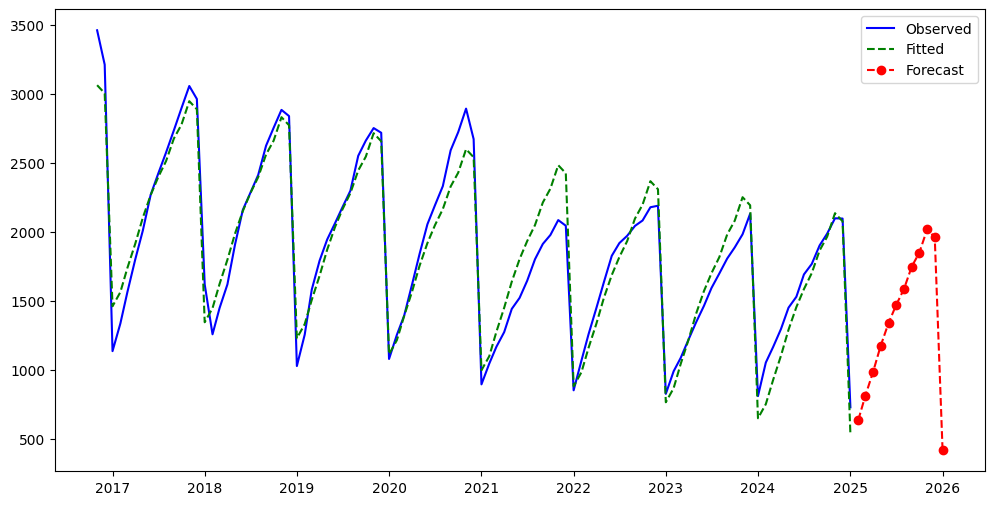

In [9]:
# Предположим, у вас месячные данные
df_dp = df_dp.sort_index()

# Устанавливаем частоту (если пропущены месяцы, могут быть NaN)
df_dp = df_dp.asfreq('MS')

dp = DeterministicProcess(
    index=df_dp.index,    
    order=1,           
    seasonal=True,     
    period=12,         
    drop=True          
)

X = dp.in_sample()
y = df_dp['Total Crimes']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Прогноз на 12 шагов вперёд
X_future = dp.out_of_sample(steps=12)
X_future = sm.add_constant(X_future, has_constant='add')
y_forecast = model.predict(X_future)

plt.figure(figsize=(12, 6))
plt.plot(df_dp.index, y, label="Observed", color='blue')
plt.plot(df_dp.index, model.predict(X), label="Fitted", linestyle='--', color='green')
plt.plot(X_future.index, y_forecast, label="Forecast", linestyle='--', marker='o', color='red')
plt.legend()
plt.show()


## Seasonality: Seasonal plot

                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     97.17
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           1.17e-44
Time:                        16:05:35   Log-Likelihood:                -643.45
No. Observations:                  99   AIC:                             1313.
Df Residuals:                      86   BIC:                             1347.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1491.2717     65.378     22.810      0.0

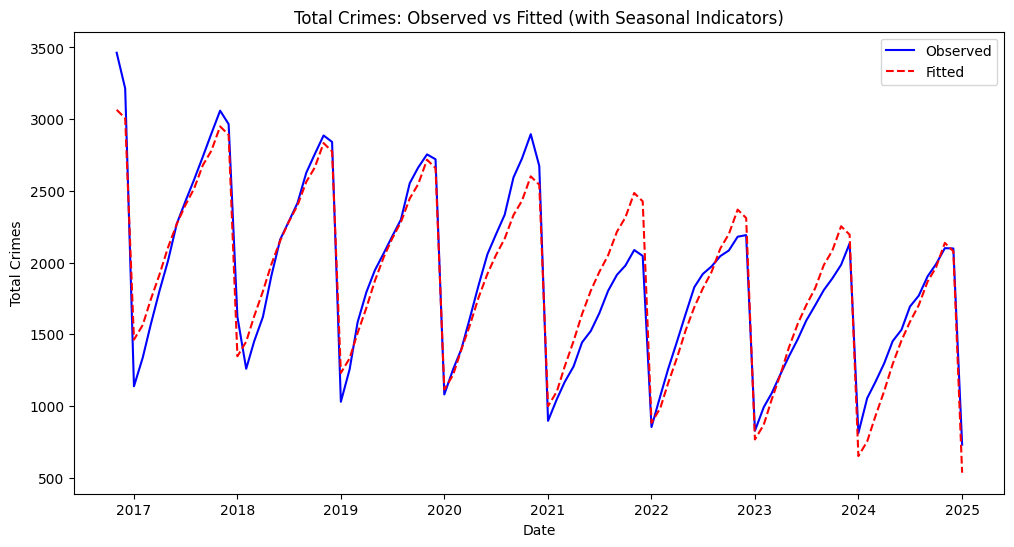

In [10]:
df_sp = df[["Date", "Month", "Total Crimes"]].copy()

# Создаем сезонные индикаторы с помощью one-hot encoding
# drop_first=True, чтобы избежать мультиколлинеарности (одна из категорий станет базовой)
seasonal_dummies = pd.get_dummies(df_sp['Month'], prefix='month', drop_first=True)

# Объединяем исходный DataFrame с бинарными признаками
df_seasonal = pd.concat([df_sp, seasonal_dummies], axis=1)

# Добавляем трендовую переменную (например, порядковый номер наблюдения)
df_seasonal['trend'] = range(1, len(df_seasonal) + 1)

# Определяем признаки для модели: тренд + сезонные индикаторы
X = df_seasonal[['trend'] + list(seasonal_dummies.columns)]
y = df_seasonal['Total Crimes']

# Добавляем константу для модели
X = sm.add_constant(X)

# Приведем все столбцы X к типу float
X = X.astype(float)

# Обучаем модель линейной регрессии
model = sm.OLS(y, X).fit()

# Выводим сводку модели
print(model.summary())

# Можно построить график подогнанных значений
df_seasonal['fitted'] = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(df_seasonal['Date'], y, label="Observed", color='blue')
plt.plot(df_seasonal['Date'], df_seasonal['fitted'], label="Fitted", linestyle='--', color='red')
plt.xlabel("Date")
plt.ylabel("Total Crimes")
plt.title("Total Crimes: Observed vs Fitted (with Seasonal Indicators)")
plt.legend()
plt.show()

## Seasonality: Fourier Features

                            OLS Regression Results                            
Dep. Variable:           Total Crimes   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     82.86
Date:                Tue, 08 Apr 2025   Prob (F-statistic):           1.07e-36
Time:                        17:50:07   Log-Likelihood:                -677.13
No. Observations:                  99   AIC:                             1370.
Df Residuals:                      91   BIC:                             1391.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2347.3321     47.138     49.797      0.0

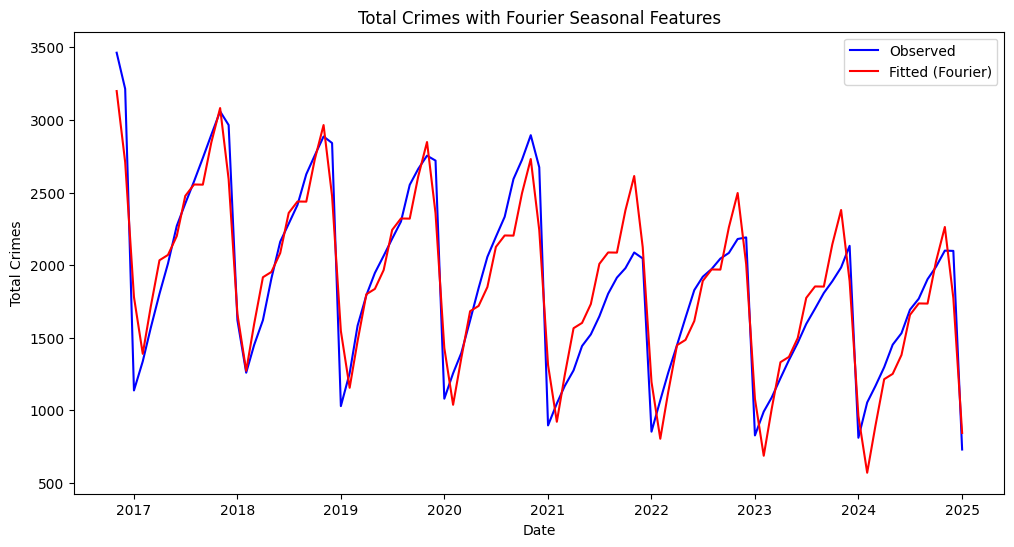

In [ ]:
df_fourier = df[["Date", "Total Crimes"]].copy()
df_fourier = df_fourier.sort_values("Date")
df_fourier = df_fourier.set_index("Date")
df_fourier = df_fourier.asfreq("MS")

y = df_fourier["Total Crimes"]

def fourier_features(index, period, K):
    """
    Создает 2*K Fourier-признаков (синус/косинус) для заданного DatetimeIndex.
    
    index  : DatetimeIndex
    period : Период сезонности (12 для месячных данных, 365 для дневных)
    K      : Количество гармоник
    """
    t = np.arange(len(index))
    # Преобразуем период в "количество шагов" (для месячных = 12, для дневных = 365)
    # Формула для омега = 2*pi / period
    w = 2 * np.pi / period
    
    # Словарь для хранения признаков
    data = {}
    for k in range(1, K+1):
        data[f'sin_{k}'] = np.sin(k * w * t)
        data[f'cos_{k}'] = np.cos(k * w * t)
    
    return pd.DataFrame(data, index=index)

# Выбираем, к примеру, 12-месячную сезонность и 3 гармоники
period = 12  
K = 3

X_fourier = fourier_features(df_fourier.index, period=period, K=K)

# Линейный тренд: порядковый номер наблюдения
X_fourier['trend'] = range(len(X_fourier))

# Добавляем константу
X_fourier = sm.add_constant(X_fourier)

# Удаляем возможные NaN (если есть пропуски в данных)
y = y.dropna()
X_fourier = X_fourier.loc[y.index].dropna()

# Обучаем модель линейной регрессии (OLS)
model = sm.OLS(y, X_fourier).fit()
print(model.summary())

df_fourier['fitted_fourier'] = model.predict(X_fourier)

plt.figure(figsize=(12,6))
plt.plot(df_fourier.index, df_fourier['Total Crimes'], label='Observed', color='blue')
plt.plot(df_fourier.index, df_fourier['fitted_fourier'], label='Fitted (Fourier)', color='red')
plt.xlabel('Date')
plt.ylabel('Total Crimes')
plt.title('Total Crimes with Fourier Seasonal Features')
plt.legend()
plt.show()


Судя по сводке, модель с Fourier-признаками (3 гармоники) и линейным трендом даёт:

R-squared ≈ 0.864

Модель объясняет около 86% вариации целевой переменной.

Это несколько ниже, чем в случае с сезонными индикаторами (где было ~0.918), но всё ещё довольно высокий показатель.

Сезонные компоненты (sin_k и cos_k):

sin
⁡
1
sin 
1
​
  и 
cos
⁡
1
cos 
1
​
  имеют самые большие и статистически значимые коэффициенты. Это логично, так как они описывают «основную волну» (с частотой 1 цикл в год).

sin
⁡
2
sin 
2
​
  оказался незначим (p-value ~ 0.68), тогда как 
cos
⁡
2
cos 
2
​
  — наоборот, значим. Это говорит, что вторая гармоника (2 цикла в год) может быть слабо выражена в синусной фазе, но заметна в косинусной.

sin
⁡
3
sin 
3
​
  и 
cos
⁡
3
cos 
3
​
  тоже оказались значимы, значит в данных присутствуют колебания на частоте 3 цикла в год (примерно каждые 4 месяца).

Тренд:

Коэффициент 
−
9.7519
−9.7519 при trend говорит о том, что, согласно модели, есть устойчивое снижение на ~9.75 единиц за каждый дополнительный шаг времени (месяц, если индекс у вас месячный).

Если это интерпретировать буквально: с каждым месяцем «базовый уровень» уменьшается примерно на 10 преступлений.

Что можно сделать дальше?

Оценить график остатков (residuals) — посмотреть, нет ли в них структуры, не учтённой моделью.

Убрать незначимые гармоники. Например, раз 
sin
⁡
2
sin 
2
​
  имеет p-value 0.68, можно попробовать исключить его из модели и посмотреть, улучшится ли качество.

Изменить число гармоник (K). Если годовая сезонность сложная, можно увеличить K, но есть риск переобучения. Если сезонность более простая, можно уменьшить K.

Сравнить с моделью на сезонных индикаторах. Вы уже видите, что модель с бинарными индикаторами показала R² ~0.918, тогда как здесь ~0.864. Возможно, для ваших данных индикаторы лучше описывают сезонность.

В итоге, Fourier-признаки дают гибкую аппроксимацию сезонности с помощью нескольких «волн». У вас получился неплохой результат, но чуть хуже, чем с индикаторами. Это может быть связано с тем, что ваша сезонность не просто гладкая волна, а может иметь резкие пики, которые индикаторы «ловят» лучше.

## Seasonality: Total crimes by month for each year

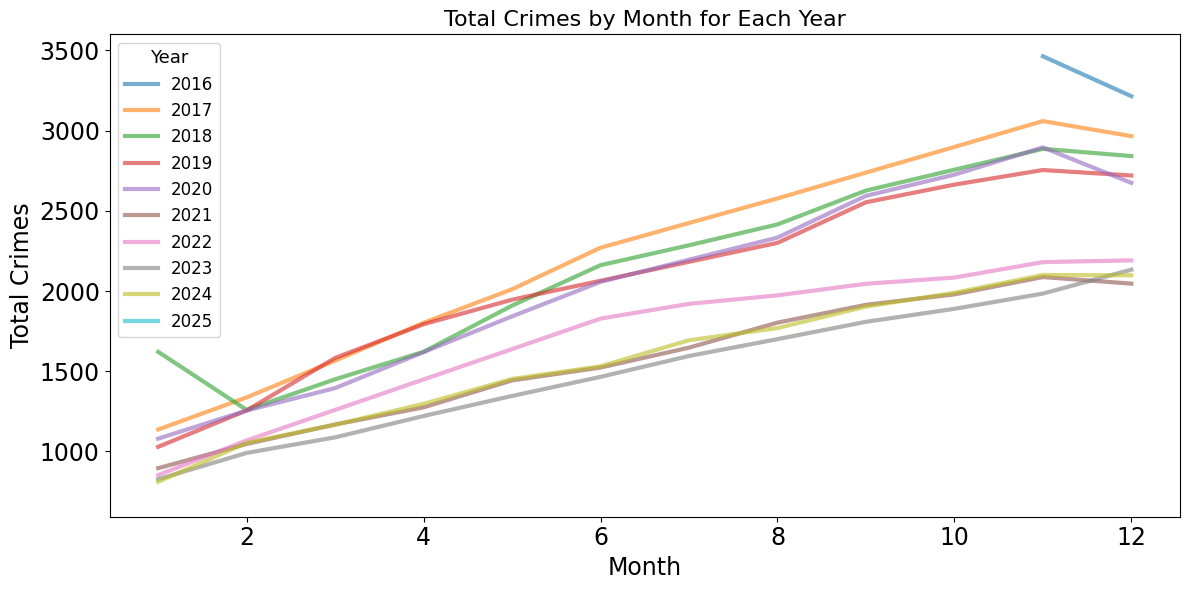

In [23]:
df_graph = df[["Date", "Total Crimes"]].copy()

df_graph['Date'] = pd.to_datetime(df_graph['Date'])
df_graph = df_graph.sort_values('Date')

# Создаем новые столбцы: год и день года
df_graph['year'] = df_graph['Date'].dt.year
df_graph['month'] = df_graph['Date'].dt.month

# Построение графика: для каждого года строим линию по дню года
plt.figure(figsize=(12, 6))
for year, group in df_graph.groupby('year'):
    plt.plot(group['month'], group['Total Crimes'], label=str(year), alpha=0.6, linewidth=3)

plt.xlabel('Month', fontsize=17)
plt.ylabel('Total Crimes', fontsize=17)
plt.title('Total Crimes by Month for Each Year', fontsize=16)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.legend(title="Year", fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.show()

На Рисунке X показана динамика преступлений по месяцам для каждого года. Видно, что для всех лет кривые имеют монотонный рост от начала года (январь) к концу (декабрь). Это говорит о том, что количество зарегистрированных преступлений в течение года стабильно увеличивается. При этом для разных лет абсолютный уровень (начальные и конечные значения) может отличаться, но общая форма (низкие значения в начале года и высокие — в конце) сохраняется.

Подобное поведение может указывать на внутригодовую сезонность, когда минимумы приходятся на ранние месяцы, а максимумы — на последние. Возможные причины такой тенденции могут включать социально-экономические факторы, календарные особенности или оперативные особенности учёта преступлений (например, некоторые преступления фиксируются в конце года). Для точного объяснения стоит дополнительно изучить факторы, влияющие на распределение преступлений по месяцам.

Важные моменты:

Монотонный рост в течение года: может означать либо реальное накопление случаев, либо особенности учёта (в конце года собирают больше данных).

Различия по годам: амплитуда (начальный и конечный уровень) варьируется, что может указывать на общий тренд или внешние факторы, меняющиеся из года в год.

Сезонность: обычно подразумевает «волнообразное» поведение, но здесь мы видим именно «восходящую линию» — тоже вариант сезонной структуры, где «низкий сезон» в начале года и «высокий сезон» в конце.

Таким образом, график наглядно демонстрирует, что внутри одного календарного года преступления растут от месяца к месяцу, а сопоставление разных лет помогает увидеть общую динамику и сравнить уровни преступности между ними.

## Seasonality: Periodogram

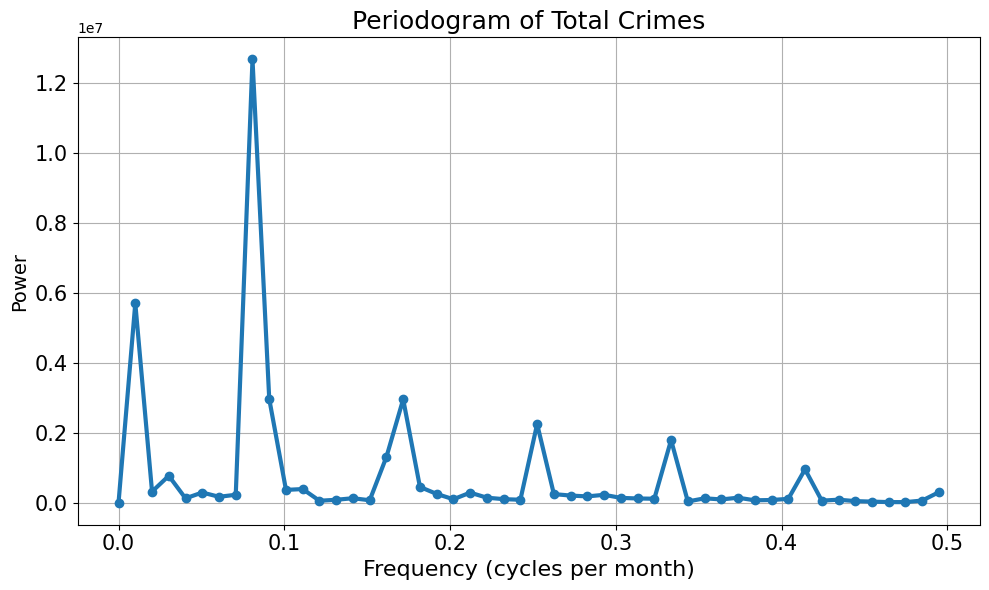

In [30]:
from scipy.signal import periodogram

# Prepare the time series
df_periodogram = df[["Date", "Total Crimes"]].copy()
df_periodogram['Date'] = pd.to_datetime(df_periodogram['Date'])
df_periodogram = df_periodogram.sort_values('Date')
df_periodogram = df_periodogram.set_index('Date')

# Extract the time series and drop missing values
y = df_periodogram['Total Crimes'].dropna()

# For monthly data, the sampling frequency fs = 1 (one observation per month)
fs = 1

# Compute the periodogram
frequencies, power = periodogram(y, fs=fs)

# Plot the periodogram with larger fonts
plt.figure(figsize=(10, 6))
plt.plot(frequencies, power, marker='o', linestyle='-', linewidth=3)
plt.xlabel('Frequency (cycles per month)', fontsize=16)
plt.ylabel('Power', fontsize=14)
plt.title('Periodogram of Total Crimes', fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()

На периодограмме виден выраженный пик в районе частоты около 0.08 циклов в месяц. Если перевести это в период (количество месяцев на один цикл), получим:

Период ≈ $\frac{1}{0.08}$ = 12.5 месяцев.


Это близко к 12 месяцам, что говорит о годовой сезонности. То есть самые сильные колебания в ваших данных повторяются примерно раз в год.

Кроме того, можно заметить более мелкие пики на других частотах, но основной «сплеск» мощности именно возле 
0.08
0.08. Это подтверждает, что в данных присутствует явно выраженный годовой паттерн (сезонность), а остальные частоты вносят меньший вклад.

Если вы работаете с помесячными данными, этот результат согласуется с тем, что мы видели ранее: графики по месяцам показывают возрастание преступлений к концу года, и периодограмма указывает, что наиболее мощная волна в данных — это волна с периодом около года.


# Serial dependence

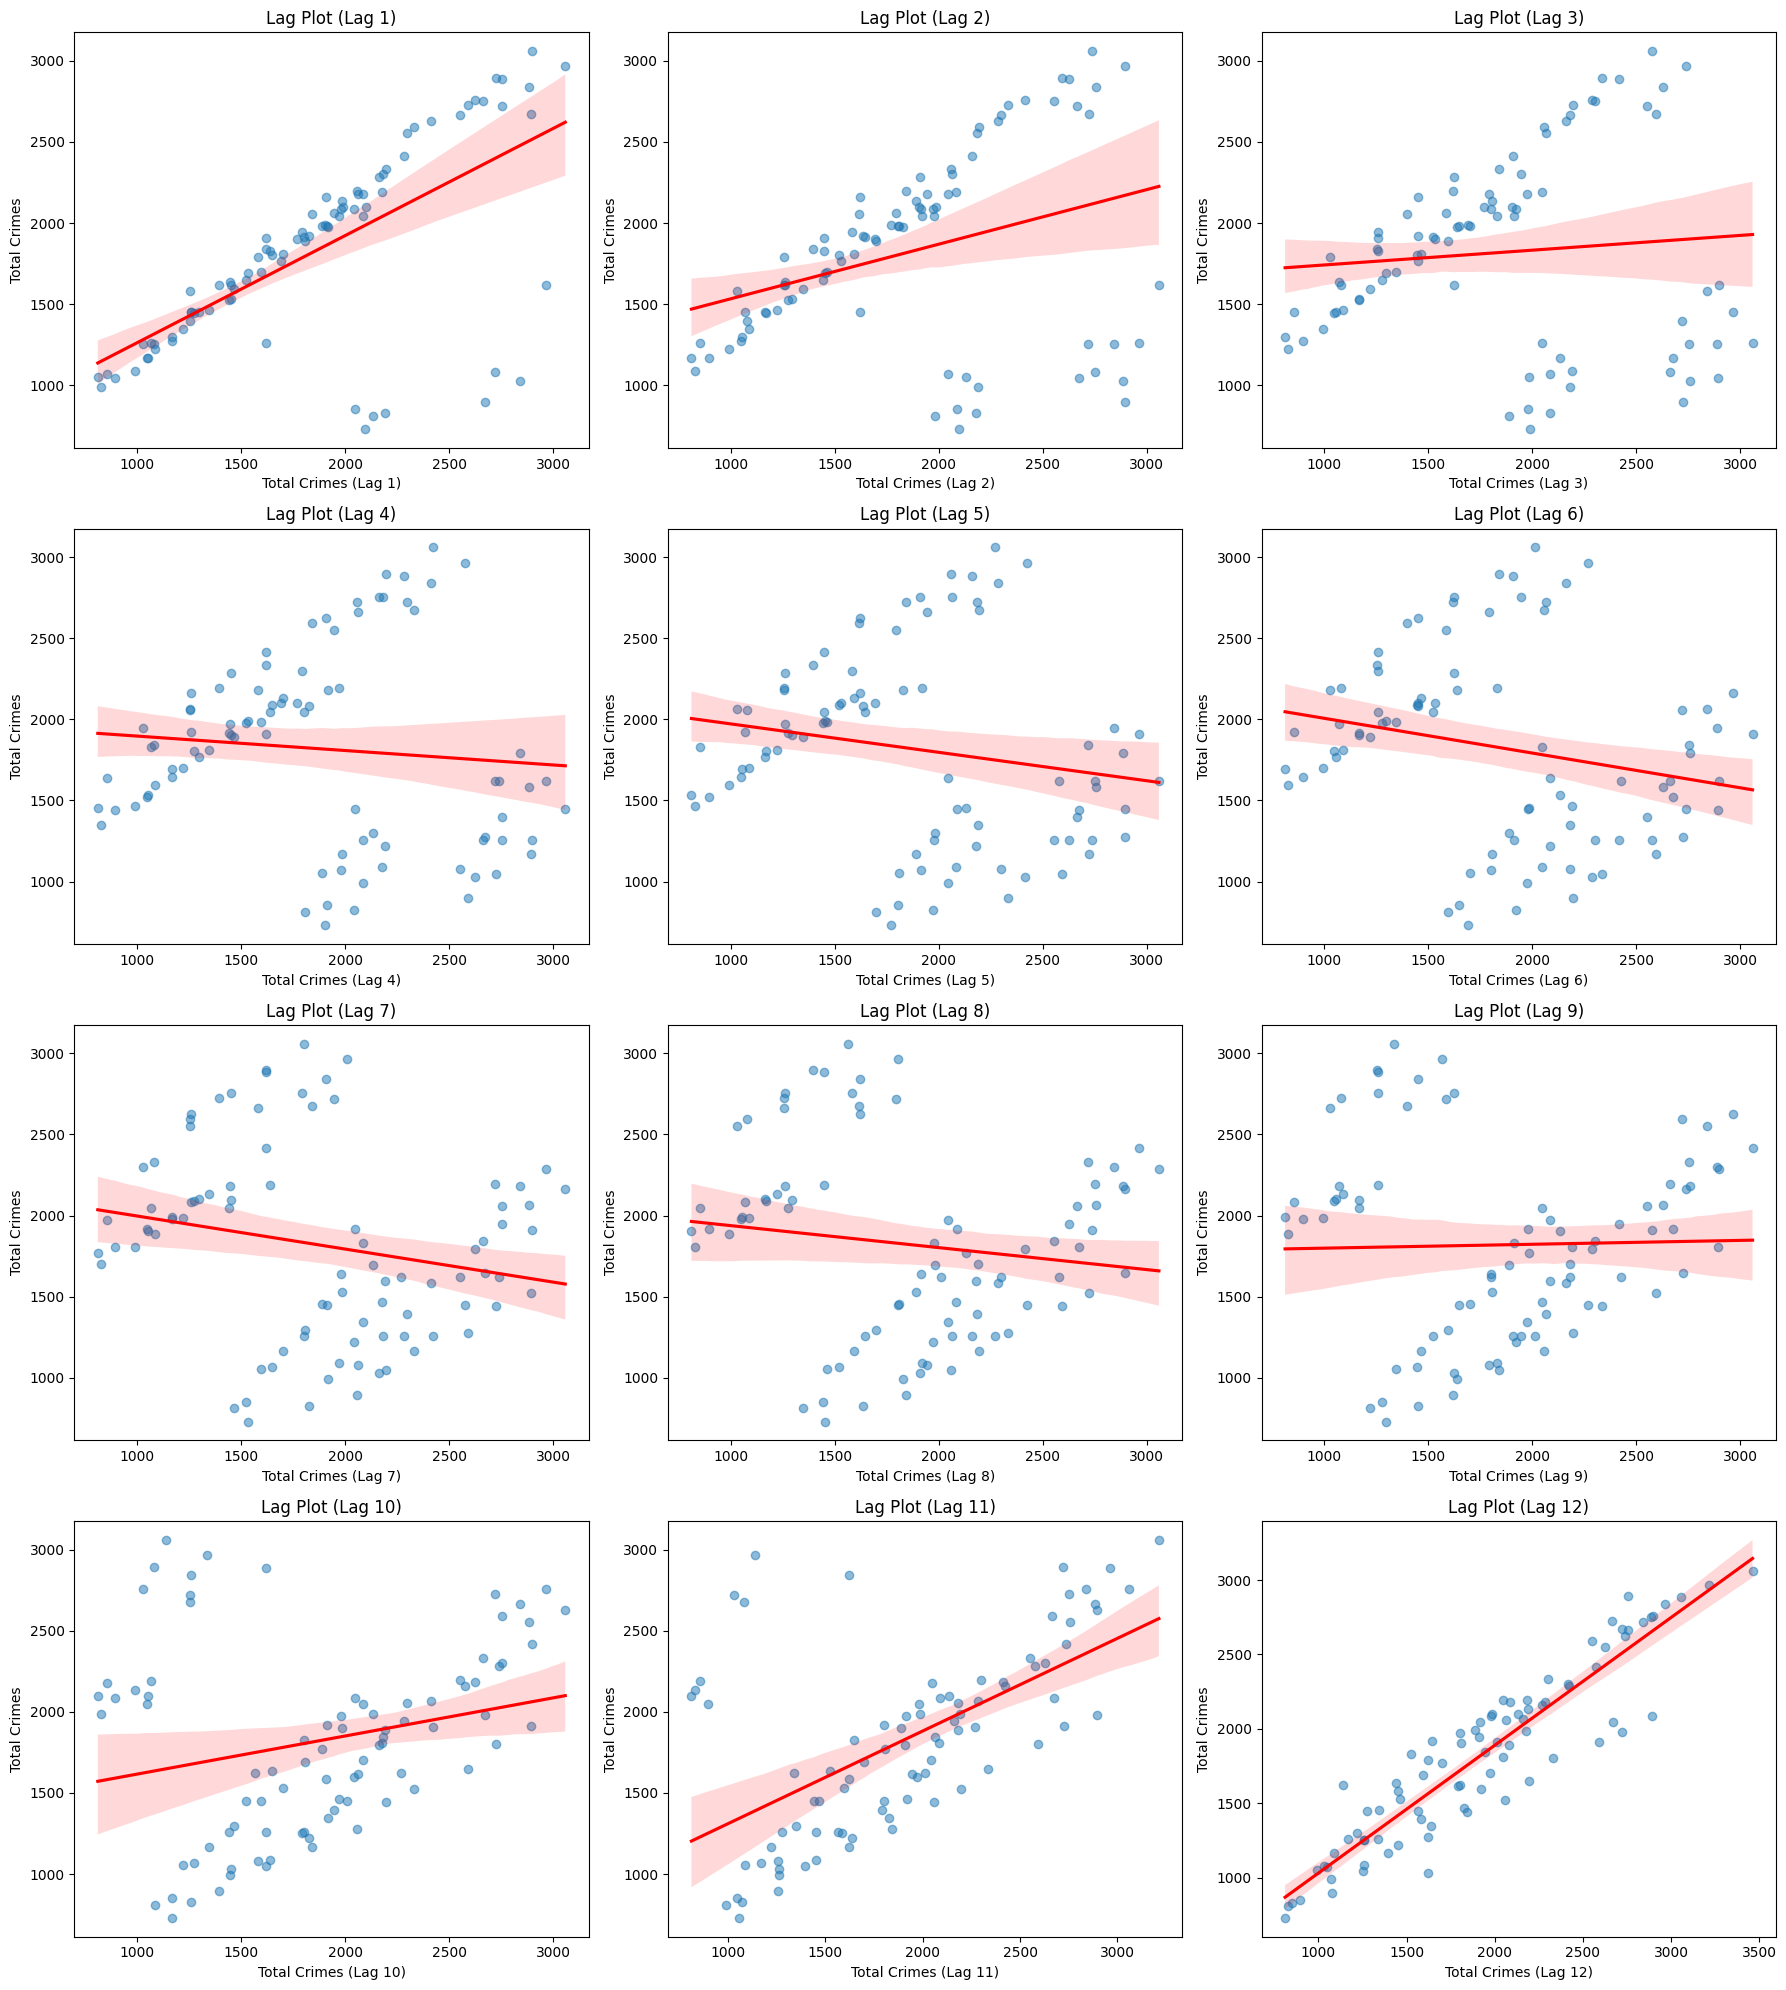

In [36]:
# Copy and prepare the data
df_sd = df[['Month', 'Year', 'Total Crimes']].copy()

# Choose the number of lags
max_lag = 12

# Create lag features
for lag in range(1, max_lag + 1):
    df_sd[f'Lag_{lag}'] = df_sd['Total Crimes'].shift(lag)

# Drop missing values caused by lags
df_sd = df_sd.dropna()

# Plot settings
cols = 3  # Number of plots per row
rows = int(np.ceil(max_lag / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

for i, lag in enumerate(range(1, max_lag + 1)):
    r, c = divmod(i, cols)
    ax = axes[r, c] if rows > 1 else axes[c]
    sns.regplot(
        x=df_sd[f'Lag_{lag}'],
        y=df_sd['Total Crimes'],
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"},
        ax=ax
    )
    ax.set_title(f'Lag Plot (Lag {lag})')
    ax.set_xlabel(f'Total Crimes (Lag {lag})')
    ax.set_ylabel('Total Crimes')

# Hide empty subplots if any
for j in range(max_lag, rows * cols):
    r, c = divmod(j, cols)
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')

plt.tight_layout()
plt.show()


In [35]:
df_sd

,Month,Year,Total Crimes,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Lag_6
6,5,2017,2011.0,1802.0,1566.0,1337.0,1137.0,3214.0,3463.0
7,6,2017,2270.0,2011.0,1802.0,1566.0,1337.0,1137.0,3214.0
8,7,2017,2424.0,2270.0,2011.0,1802.0,1566.0,1337.0,1137.0
9,8,2017,2577.0,2424.0,2270.0,2011.0,1802.0,1566.0,1337.0
10,9,2017,2738.0,2577.0,2424.0,2270.0,2011.0,1802.0,1566.0
...,...,...,...,...,...,...,...,...,...
94,9,2024,1903.0,1769.0,1693.0,1531.0,1452.0,1297.0,1167.0
95,10,2024,1989.0,1903.0,1769.0,1693.0,1531.0,1452.0,1297.0
96,11,2024,2100.0,1989.0,1903.0,1769.0,1693.0,1531.0,1452.0
97,12,2024,2098.0,2100.0,1989.0,1903.0,1769.0,1693.0,1531.0


## Partial autocorrelation

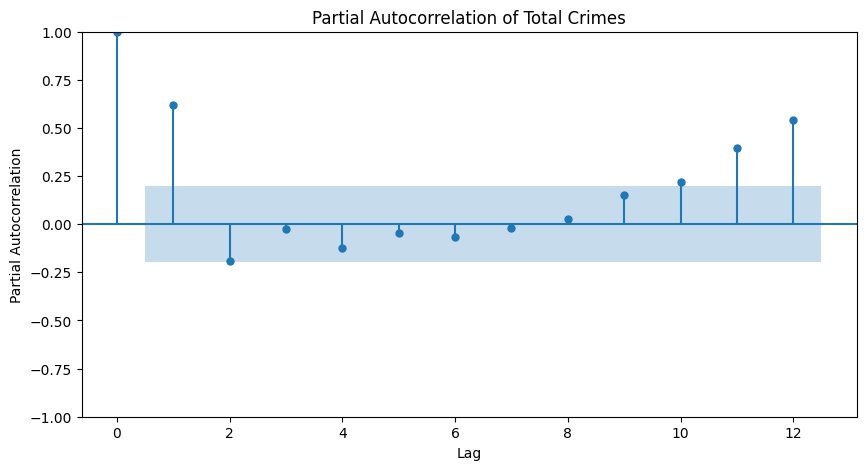

In [16]:
from statsmodels.graphics.tsaplots import plot_pacf

# Предполагается, что DataFrame df содержит колонки "Date" и "Total Crimes"
df_pacf = df[['Date', 'Total Crimes']].copy()

# Преобразуем дату и сортируем
df_pacf['Date'] = pd.to_datetime(df_pacf['Date'])
df_pacf = df_pacf.sort_values('Date').set_index('Date')

# Извлекаем сам временной ряд
y = df_pacf['Total Crimes'].dropna()

# Строим PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(y, ax=ax, method='ywm', lags=12)  # method='ywm' или 'ols' (какой предпочитаешь)
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.title('Partial Autocorrelation of Total Crimes')
plt.show()

Судя по графику частичной автокорреляции (PACF):

Лаг 1 сильно выходит за пределы доверительного интервала, причём положительно.

Это означает, что значение ряда в текущем месяце сильно зависит от значения в предыдущем месяце (после учёта других лагов).

Для лагов 2, 3 и дальше столбцы находятся в пределах синей зоны (доверительного интервала) или совсем незначительно выходят за её границы.

Это говорит, что прямое влияние более ранних значений (2 месяца назад, 3 месяца назад и т. д.) либо слабое, либо перекрывается эффектом от лаг-1.

Возможно, у лагов 11 или 12 есть небольшой всплеск, что иногда свидетельствует о годовой сезонности (если он статистически значим). Однако по графику кажется, что значения не так сильно выходят за доверительный интервал, как лаг 1.

На графике частичной автокорреляции (PACF) из statsmodels синим прямоугольником (или синими «полосами») отображается доверительный интервал вокруг нуля. Обычно это 
±
2
±2 стандартные ошибки.

Если столбец выходит за границы этого голубого диапазона, значит соответствующая частичная автокорреляция статистически значима, и можно говорить, что лаг вносит существенный вклад. Если же столбец «прячется» внутри синих границ, то с точки зрения статистики нет уверенности, что автокорреляция на этом лаге отличается от нуля.